In [1]:
from osgeo import ogr, gdal
import pandas as pd
import numpy as np
import os
#%matplotlib inline
import matplotlib.pyplot as plt
import seaborn as sns
from pyproj import Proj, transform
#import PyYAML
import json
import requests
import urllib3

In [2]:
# Define the name of the environment and the output file
#import os 
#env_name = "pygdal4"  # Replace with your environment name
#output_file = "020325pygdalenvironment.yml"

# Use os.system to run the conda command
#os.system(f"conda env export -n {env_name} > {output_file}")

#print(f"Environment {env_name} has been exported to {output_file}")

In [3]:
#Need to replace dem tiff conversion here 

In [4]:
#Can retrive from Google Earth Engine Here : https://code.earthengine.google.com/50dfe2989a6f7c96ae4dc3433ef34110
#copy link above to obtain geotiff download of DEM 
ds5 = gdal.Open('NASA_DEM_NHFAOI.tif') #read-in DEM file as geotiff of the area of interest. If downloaded from google earth engine, actual filename is "NASA_JPL_DEM_30M.tif"
type(ds5)
ds5.RasterXSize, ds5.RasterYSize

(941, 1232)

In [5]:
ds5.GetGeoTransform()

(-105.42478877866701,
 0.0002694945852358564,
 0.0,
 39.367902937816964,
 0.0,
 -0.0002694945852358564)

In [6]:
array5 = ds5.GetRasterBand(1).ReadAsArray()

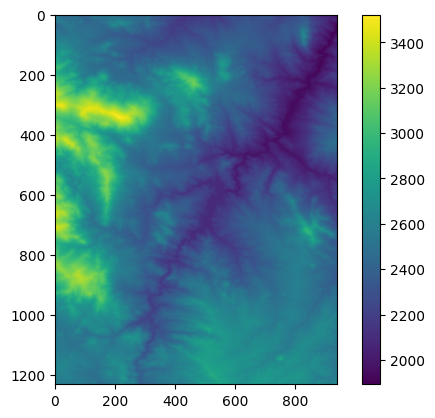

In [7]:
#Raw Dem acquired from GEE
#array5 = ds5.GetRasterBand(1).ReadAsArray()
plt.imshow(array5)
plt.colorbar()

In [8]:
print(ds5.GetProjection())

GEOGCS["WGS 84",DATUM["WGS_1984",SPHEROID["WGS 84",6378137,298.257223563,AUTHORITY["EPSG","7030"]],AUTHORITY["EPSG","6326"]],PRIMEM["Greenwich",0,AUTHORITY["EPSG","8901"]],UNIT["degree",0.0174532925199433,AUTHORITY["EPSG","9122"]],AXIS["Latitude",NORTH],AXIS["Longitude",EAST],AUTHORITY["EPSG","4326"]]


In [9]:
ds5.GetGeoTransform()

(-105.42478877866701,
 0.0002694945852358564,
 0.0,
 39.367902937816964,
 0.0,
 -0.0002694945852358564)

In [10]:
#create output bounds
#outputBounds:
        #output bounds as (minX, minY, maxX, maxY) in target SRS
minX = 463049.10869513 #(Left -Arc Map)
minY = 4320647.33108 #(Bottom - Arc Map)
maxX = 485339.108695 #(Right - AM) 
maxY = 4357817.3310783 #(Top - AM)
#WKTs for in and out projection
outproj = "EPSG_26913"
inproj = "EPSG_4326"
aoi_bound = minX, minY, maxX, maxY
aoi_bound

(463049.10869513, 4320647.33108, 485339.108695, 4357817.3310783)

In [11]:
import datetime as dt
now = (dt.datetime.now().date())
now

datetime.date(2025, 2, 20)

In [12]:
filein = str(now) +'_' + inproj + '_' + 'DEM_ReProj_In' + '.asc'
filein
fileout = str(now) +'_' + outproj + '_' + 'DEM_ReProj_Out' + '.asc'
fileout

'2025-02-20_EPSG_26913_DEM_ReProj_Out.asc'

In [13]:
outproj_b = outproj.replace('_', ':')
inproj_b = inproj.replace('_', ':')
inproj_b, outproj_b

('EPSG:4326', 'EPSG:26913')

In [14]:
#For the other DEMs with the -9999 nodata number, uncomment out to run. Below is for VELMA simulations DEM flat processing
#dsRes = gdal.Warp(filein, ds5, dstSRS = "EPSG:26913", xRes = 30, yRes =30, outputBounds = aoi_bound, dstNodata= -9999) # almost correct but has nodata value header incorrect

In [15]:
dsRes = gdal.Warp(filein, ds5, dstSRS = outproj_b, xRes = 30, yRes =30, outputBounds = aoi_bound, dstNodata= 1) # almost correct but has nodata value header incorrect
#e.g. 2024-09-11_EPSG_26913_DEM_ReProj_In.asc

In [16]:
dsRes.GetGeoTransform()

(463049.10869513, 30.0, 0.0, 4357817.3310783, 0.0, -30.0)

In [17]:
#only necessary for VELMA DEMs, not other LSMs. 
df_ds_res2 = pd.read_csv(filein, header=None)
df_ds_res2[0:7][0:6]
#df_ds_res2.info()

,0
0,ncols 743
1,nrows 1239
2,xllcorner 463049.108695129980
3,yllcorner 4320647.331078300253
4,cellsize 30.000000000000
5,NODATA_value 1


In [18]:
#only necessary for VELMA DEMs, not other LSMS e.g. #2024-09-11_EPSG_26913_DEM_ReProj_Out.asc
df_ds_res2.replace({'NODATA_value 1': 'NODATA_value -9999'}).to_csv(fileout, header=None, index=False)

In [19]:
#Read file into JPDEM as a DEM File to be flat processed. Get Filename 

In [20]:
#Data Acquisition Preprocessing 
#Acquisition File 

In [21]:
#Replace your flat processed DEM from JPDEM Here 
ds = gdal.Open('NHFAOI_DEM_743c_1239r_fp_exp_enh.asc')
type(ds)

osgeo.gdal.Dataset

In [22]:
type(ds)

osgeo.gdal.Dataset

In [23]:
ds.RasterXSize, ds.RasterYSize

(743, 1239)

In [24]:
ds.GetGeoTransform()

(463049.10869513, 30.0, 0.0, 4357817.3310783, 0.0, -30.0)

In [25]:
array1 = ds.GetRasterBand(1).ReadAsArray()
#flat processed version of the DEM above 

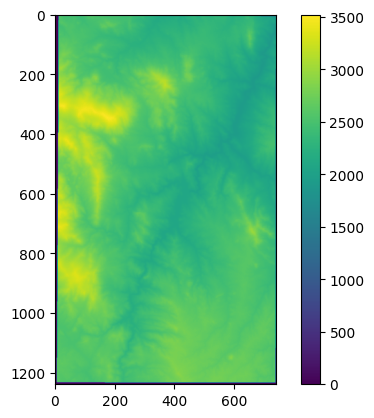

In [26]:
plt.imshow(array1)
plt.colorbar()

In [27]:
ds = None 

In [28]:
ds2 = gdal.Open('BCReachOutletsMap.asc') #use reachoutletsmap.asc from JPDEM after determining watershed delineation from watershed charactericistics
ds2.RasterXSize, ds2.RasterYSize
#use a mask for data acquistion since this is climate drivers outside of watershed delineation would throw an error during VELMA simiulations

(743, 1239)

In [29]:
array2 = ds2.GetRasterBand(1).ReadAsArray()

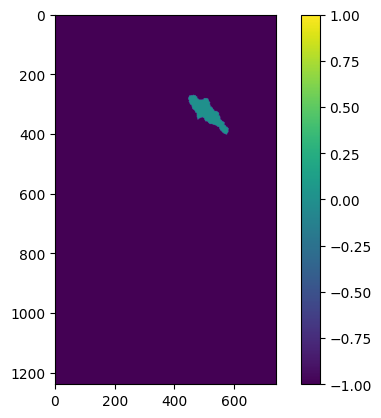

In [30]:
plt.imshow(array2)
plt.colorbar()

In [31]:
#ds2 = None

In [32]:
#Chekcing the new transformation for the Resoultion and reprojection update

In [33]:
dsRes.GetGeoTransform()

(463049.10869513, 30.0, 0.0, 4357817.3310783, 0.0, -30.0)

In [34]:
dsRes.GetGeoTransform()[0], dsRes.GetGeoTransform()[3]

(463049.10869513, 4357817.3310783)

In [35]:
demfileout = str(now) +'_' + outproj + '_'  +'DEM' + '.xyz'
demfileout

'2025-02-20_EPSG_26913_DEM.xyz'

In [36]:
#Correct to translate into readable format for datafrome reading
#Need to create naming convention for this!!!!!!
#Exports file xyz 
xyz = gdal.Translate(demfileout, dsRes)

In [37]:
xyz = None 

In [38]:
df_test2 = pd.read_csv(demfileout, sep = " ", header = None)
df_test2.columns = ["x", "y", "value"]
df_test2.head()

,x,y,value
0,463064.108695,4.357802e+06,1
1,463094.108695,4.357802e+06,1
2,463124.108695,4.357802e+06,1
3,463154.108695,4.357802e+06,1
4,463184.108695,4.357802e+06,1


In [39]:
df_test2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 920577 entries, 0 to 920576
Data columns (total 3 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   x       920577 non-null  float64
 1   y       920577 non-null  float64
 2   value   920577 non-null  int64  
dtypes: float64(2), int64(1)
memory usage: 21.1 MB


In [40]:
df_test2.describe()

,x,y,value
count,920577.000000,9.205770e+05,920577.000000
mean,474194.108695,4.339232e+06,2441.031737
std,6434.566417,1.073006e+04,488.280322
min,463064.108695,4.320662e+06,1.000000
25%,468614.108695,4.329932e+06,2296.000000
50%,474194.108695,4.339232e+06,2484.000000
75%,479774.108695,4.348532e+06,2649.000000
max,485324.108695,4.357802e+06,3522.000000


In [41]:
gt1 = dsRes.GetGeoTransform() #DEM transformation for AOI ASCII to obtain similar raster indicies 
print(gt1)

(463049.10869513, 30.0, 0.0, 4357817.3310783, 0.0, -30.0)


In [42]:
dsRes = None

In [43]:
from osgeo import ogr

# Convert projected coordinates to raster cell indices
def parse_coords(x,y,gt):
    row,col = None,None
    if x:
        col = int((x - gt[0]) // gt[1])
        # If only x coordinate is provided, return column index
        if not y:
            return col
    if y:
        row = int((y - gt[3]) // gt[5])
        # If only x coordinate is provided, return column index
        if not x:
            return row
    return (row,col)

In [44]:
parse_coords(463064.10869513, 4357802.3310783, gt1) #validates first point for parse_coords gridded cell index

(0, 0)

In [45]:
parse_coords(476294.108695, 4340012, gt1) #validating transformation for DEM ASCII Transformation

(593, 441)

In [46]:
df_test2.x[0]

463064.10869513

In [47]:
#style 2 of pyproj from updated code test 
from pyproj import Transformer 
transformer = Transformer.from_crs('epsg:26913', 'epsg:4326')
x2_test, y2_test = transformer.transform(df_test2.x[0], df_test2.y[0])
print(df_test2.x[0], df_test2.y[0])
print(x2_test, y2_test) 
#no error statement and will use this ongoing to upgrade to pyproj2 8/29/24!

463064.10869513 4357802.3310783
39.368897276850504 -105.42878594919762


In [48]:
#New Pyproj2 update for transformation of the grid cells 8/29/24! Removes error 
df_test2['lat'], df_test2['long'] = transformer.transform(df_test2.x[:], df_test2.y[:])

In [49]:
df_test2.head()

,x,y,value,lat,long
0,463064.108695,4.357802e+06,1,39.368897,-105.428786
1,463094.108695,4.357802e+06,1,39.368899,-105.428438
2,463124.108695,4.357802e+06,1,39.368900,-105.428089
3,463154.108695,4.357802e+06,1,39.368901,-105.427741
4,463184.108695,4.357802e+06,1,39.368902,-105.427393


In [50]:
"""these are corrected columns needed for cell id location (row, col)...."""
row=df_test2.iloc[0,:]
[row['x'],row['y']]

[463064.10869513, 4357802.3310783]

In [51]:
id_list =[]; row_list =[];
for row_id,row in df_test2.iterrows():
    row_list.append(parse_coords(row['x'], row['y'], gt1))
    id_list.append(row_id)

In [52]:
cellid_series =pd.Series(row_list, index= id_list, name='cell id')

In [53]:
df_2 = pd.concat([cellid_series, df_test2], axis= 1)
df_2.head(-1)

,cell id,x,y,value,lat,long
0,"(0, 0)",463064.108695,4.357802e+06,1,39.368897,-105.428786
1,"(0, 1)",463094.108695,4.357802e+06,1,39.368899,-105.428438
2,"(0, 2)",463124.108695,4.357802e+06,1,39.368900,-105.428089
3,"(0, 3)",463154.108695,4.357802e+06,1,39.368901,-105.427741
4,"(0, 4)",463184.108695,4.357802e+06,1,39.368902,-105.427393
...,...,...,...,...,...,...
920571,"(1238, 737)",485174.108695,4.320662e+06,1,39.034892,-105.171300
920572,"(1238, 738)",485204.108695,4.320662e+06,1,39.034893,-105.170953
920573,"(1238, 739)",485234.108695,4.320662e+06,1,39.034893,-105.170607
920574,"(1238, 740)",485264.108695,4.320662e+06,1,39.034894,-105.170260


In [54]:
df_2['cell id'][0]

(0, 0)

In [55]:
#Unpacking tuple in cell id to a dataframe column for each to a list for each row then append the prior index) #main dataframe 2
df_2[['xrow','ycol']] = pd.DataFrame(df_2['cell id'].tolist(),index=df_2.index)

In [56]:
df_2.info()

<class 'pandas.core.frame.DataFrame'>
Index: 920577 entries, 0 to 920576
Data columns (total 8 columns):
 #   Column   Non-Null Count   Dtype  
---  ------   --------------   -----  
 0   cell id  920577 non-null  object 
 1   x        920577 non-null  float64
 2   y        920577 non-null  float64
 3   value    920577 non-null  int64  
 4   lat      920577 non-null  float64
 5   long     920577 non-null  float64
 6   xrow     920577 non-null  int64  
 7   ycol     920577 non-null  int64  
dtypes: float64(4), int64(3), object(1)
memory usage: 95.5+ MB


In [57]:
df_2.head()

,cell id,x,y,value,lat,long,xrow,ycol
0,"(0, 0)",463064.108695,4.357802e+06,1,39.368897,-105.428786,0,0
1,"(0, 1)",463094.108695,4.357802e+06,1,39.368899,-105.428438,0,1
2,"(0, 2)",463124.108695,4.357802e+06,1,39.368900,-105.428089,0,2
3,"(0, 3)",463154.108695,4.357802e+06,1,39.368901,-105.427741,0,3
4,"(0, 4)",463184.108695,4.357802e+06,1,39.368902,-105.427393,0,4


In [58]:
df_2['cell id'][0]

(0, 0)

In [59]:
df_2['lat'][293321], df_2['long'][293321] # Partioning the latitude and longitude values to be selected

(39.26295797193767, -105.22679682913683)

In [60]:
%alias_magic t timeit

Created `%t` as an alias for `%timeit`.
Created `%%t` as an alias for `%%timeit`.


In [61]:
#filein2 = str(now) +'_' + outproj + '_' + 'DEM_ReachMap_In' + '.asc'
#filein2
fileout2 = str(now) +'_' + outproj + '_' + 'DEM_ReachMap_Out' + '.xyz' #add delineation point in naming ""
fileout2

'2025-02-20_EPSG_26913_DEM_ReachMap_Out.xyz'

In [62]:
xyz = gdal.Translate(fileout2, ds2) #need to update auto filenaming baesd on WS delineation
#to develop the flat file to read in the values from the ascii read in 

In [63]:
xyz = None 

In [64]:
df_focus_ws = pd.read_csv(fileout2, sep = " ", header = None) 
%t -n1 pass
df_focus_ws.columns = ["x", "y", "value"]
df_focus_ws.head()

314 ns ± 217 ns per loop (mean ± std. dev. of 7 runs, 1 loop each)


,x,y,value
0,463064.108695,4.357802e+06,-1
1,463094.108695,4.357802e+06,-1
2,463124.108695,4.357802e+06,-1
3,463154.108695,4.357802e+06,-1
4,463184.108695,4.357802e+06,-1


In [65]:
df_focus_ws.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 920577 entries, 0 to 920576
Data columns (total 3 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   x       920577 non-null  float64
 1   y       920577 non-null  float64
 2   value   920577 non-null  int64  
dtypes: float64(2), int64(1)
memory usage: 21.1 MB


In [66]:
df_focus_ws.value.unique()

array([-1,  0,  1], dtype=int64)

In [67]:
#outlet point delineation outlet point #need for outlet point location naming from array2
df_focus_ws.loc[df_focus_ws['value'] ==1]

,x,y,value
293321,480434.108695,4.345982e+06,1


In [68]:
#location of cells within focused watershed boundaries
df_ws_bc = df_focus_ws.loc[df_focus_ws['value'] ==0]
df_ws_bc.head()

,x,y,value
201815,476924.108695,4.349672e+06,0
201816,476954.108695,4.349672e+06,0
201817,476984.108695,4.349672e+06,0
202551,476714.108695,4.349642e+06,0
202552,476744.108695,4.349642e+06,0


In [69]:
#randomly select 3 (n=3) other points to obtain data for #random state added to ensure same value for reprodiucblity can remove 
ws_list = df_ws_bc.sample(n=3, random_state= 312).index.append(df_focus_ws.loc[df_focus_ws['value']==1].index) # included the outlet point from the delineation

In [70]:
ws_list #New listing to be added using 312 RN

Index([282902, 286626, 224142, 293321], dtype='int64')

In [71]:
df_focus_ws.iloc[df_focus_ws.index[df_ws_bc.index]]

,x,y,value
201815,476924.108695,4.349672e+06,0
201816,476954.108695,4.349672e+06,0
201817,476984.108695,4.349672e+06,0
202551,476714.108695,4.349642e+06,0
202552,476744.108695,4.349642e+06,0
...,...,...,...
298518,480314.108695,4.345772e+06,0
299258,480224.108695,4.345742e+06,0
299259,480254.108695,4.345742e+06,0
299260,480284.108695,4.345742e+06,0


In [72]:
df_focus_ws.iloc[df_focus_ws.index[df_ws_bc.index]].describe() #use these values to extrpolate for rp coverage

,x,y,value
count,6675.000000,6.675000e+03,6675.0
mean,478345.021055,4.347907e+06,0.0
std,988.507526,9.309543e+02,0.0
min,476444.108695,4.345742e+06,0.0
25%,477524.108695,4.347212e+06,0.0
50%,478304.108695,4.347932e+06,0.0
75%,479114.108695,4.348682e+06,0.0
max,480464.108695,4.349672e+06,0.0


In [73]:
df_focus_ws.iloc[df_focus_ws.index[ws_list]]

,x,y,value
282902,479924.108695,4.346402e+06,0
286626,480194.108695,4.346252e+06,0
224142,478034.108695,4.348772e+06,0
293321,480434.108695,4.345982e+06,1


In [74]:
df_2.iloc[df_focus_ws.index[ws_list]]#.to_csv('092024_New_MS2_Climate_Drivers_1.csv')

,cell id,x,y,value,lat,long,xrow,ycol
282902,"(380, 562)",479924.108695,4.346402e+06,2058,39.266731,-105.232721,380,562
286626,"(385, 571)",480194.108695,4.346252e+06,2020,39.265385,-105.229587,385,571
224142,"(301, 499)",478034.108695,4.348772e+06,2435,39.288041,-105.254707,301,499
293321,"(394, 579)",480434.108695,4.345982e+06,1994,39.262958,-105.226797,394,579


In [75]:
df_2.iloc[df_2.index[ws_list]].describe()

,x,y,value,lat,long,xrow,ycol
count,4.000000,4.000000e+00,4.000000,4.000000,4.000000,4.0000,4.00
mean,479646.608695,4.346852e+06,2126.750000,39.270779,-105.235953,365.0000,552.75
std,1095.000000,1.291743e+03,207.173639,0.011613,0.012735,43.0581,36.50
min,478034.108695,4.345982e+06,1994.000000,39.262958,-105.254707,301.0000,499.00
25%,479451.608695,4.346185e+06,2013.500000,39.264779,-105.238217,360.2500,546.25
50%,480059.108695,4.346327e+06,2039.000000,39.266058,-105.231154,382.5000,566.50
75%,480254.108695,4.346995e+06,2152.250000,39.272058,-105.228889,387.2500,573.00
max,480434.108695,4.348772e+06,2435.000000,39.288041,-105.226797,394.0000,579.00


In [76]:
#insert EDA for parameters 

<Axes: xlabel='Elevation(m)', ylabel='Frequency'>

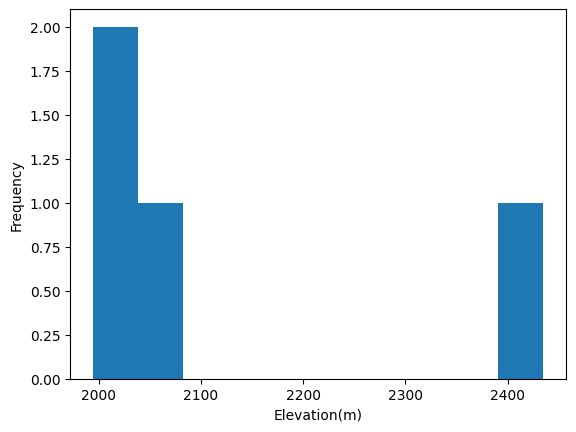

In [77]:
df_2['value'].iloc[df_2.index[ws_list]].plot(kind='hist', xlabel='Elevation(m)')

In [78]:
df_ws_list = df_2.iloc[df_2.index[ws_list]] #assinging to dataframe for data collection points within the AOI 

[Text(0, 0.5, 'Elevation (m)')]

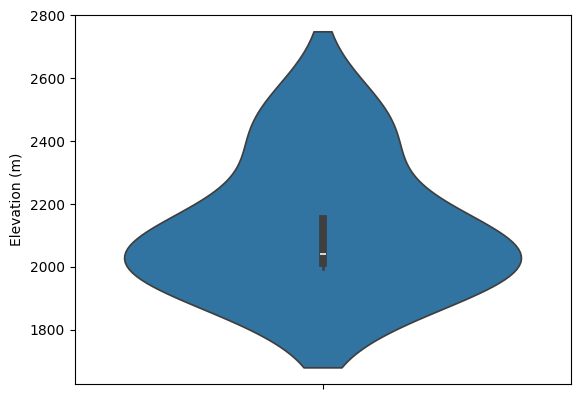

In [79]:
ax = sns.violinplot(y='value', data=df_ws_list)
ax.set(ylabel = 'Elevation (m)')

[Text(0, 0.5, 'Elevation (m)')]

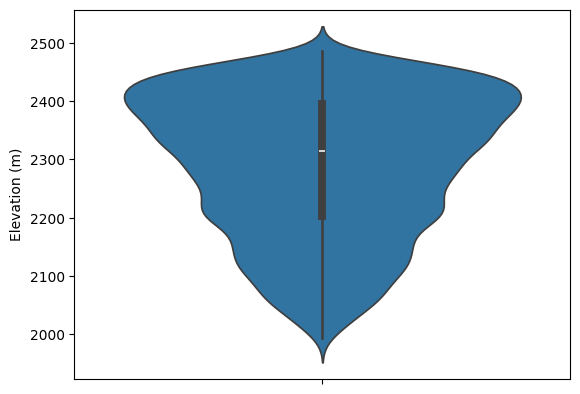

In [80]:
ax = sns.violinplot(y='value', data=df_2.iloc[df_2.index[df_ws_bc.index]])
ax.set(ylabel = 'Elevation (m)')

[Text(0, 0.5, 'Elevation (m)')]

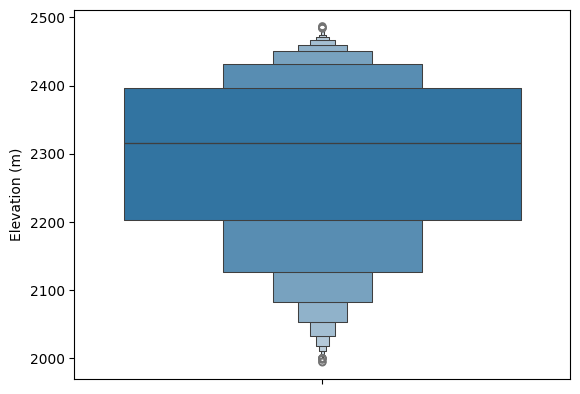

In [81]:
ax = sns.boxenplot(y='value', data=df_2.iloc[df_2.index[df_ws_bc.index]])
ax.set(ylabel = 'Elevation (m)')

[Text(0, 0.5, 'Elevation (m)')]

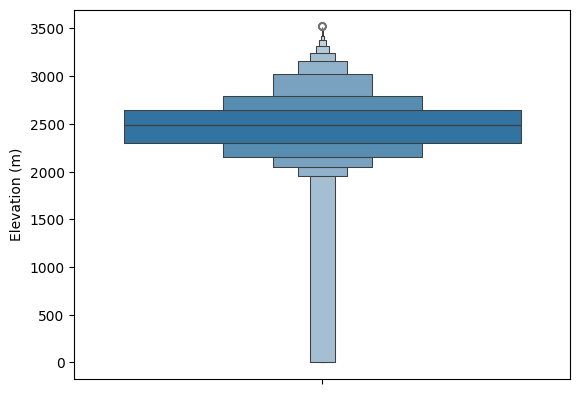

In [82]:
sns.boxenplot(y='value', data=df_2, dodge=True).set(ylabel = 'Elevation (m)') 

In [83]:
#correct accessibility of location list 
for cell in ws_list:
    print(df_2.lat.iloc[(int(cell))], df_2.long.iloc[(int(cell))])

39.266730870768285 -105.23272093716123
39.265385453920366 -105.22958669282372
39.288040681815595 -105.25470708109752
39.26295797193767 -105.22679682913683


In [84]:
import datetime as dt

In [85]:
years = (2024 - 1992) +1 
#(end year - start year) + 1 = total years data acquired
#Discovered shorter acquistion periods used in VELMA crashed 
#different data avaiability for different data sets, revised 02/02/25 to include 2024 (33 years) 
years

33

In [86]:
import numpy as np
import requests
np_year = np.linspace(1992, 2024, num=years) #number is (year_last-year_1) + 1 #updated to 24 years
int(np_year[0]) #first year in numpy array for year loop 

1992

In [87]:
datetime_series = pd.date_range('1992-01-01', periods=years, freq='Y')
#datetime_series = pd.date_range('1992-01-01', periods=years, freq='YE') --> new adaptation for future versions of annual date parsing 021925
datetime_series

C:\Users\KVENABLE\AppData\Local\Temp\ipykernel_7256\1399065672.py:1: FutureWarning: 'Y' is deprecated and will be removed in a future version, please use 'YE' instead.
  datetime_series = pd.date_range('1992-01-01', periods=years, freq='Y')


DatetimeIndex(['1992-12-31', '1993-12-31', '1994-12-31', '1995-12-31',
               '1996-12-31', '1997-12-31', '1998-12-31', '1999-12-31',
               '2000-12-31', '2001-12-31', '2002-12-31', '2003-12-31',
               '2004-12-31', '2005-12-31', '2006-12-31', '2007-12-31',
               '2008-12-31', '2009-12-31', '2010-12-31', '2011-12-31',
               '2012-12-31', '2013-12-31', '2014-12-31', '2015-12-31',
               '2016-12-31', '2017-12-31', '2018-12-31', '2019-12-31',
               '2020-12-31', '2021-12-31', '2022-12-31', '2023-12-31',
               '2024-12-31'],
              dtype='datetime64[ns]', freq='YE-DEC')

In [88]:
import json
import requests

In [89]:
#testing HMS RestAPI prior to batch collection of temperature data 
import urllib3
from urllib3.util.ssl_ import create_urllib3_context

ctx = create_urllib3_context()
ctx.load_default_certs()
ctx.options |= 0x4  # ssl.OP_LEGACY_SERVER_CONNECT
with urllib3.PoolManager(ssl_context=ctx) as http:
    r = http.request("GET", 'https://qed.epa.gov/hms/rest/api/hydrology/temperature')
    print(r.status)
    #r2 = http.request("POST",'https://qed.epa.gov/hms/rest/api/hydrology/surfacerunoff', headers=headers)
    #r2.json

200


In [90]:
import requests

headers = {
    'accept': '*/*',
    'Content-Type': 'application/json-patch+json',
}
#updated json response reflective new timezone geometry based on the removal 8/29/24 of the Google API key whcih must include "timezone": 
	# eg {"Name": "New York",
			#"Offset": -5,
			#"DLS": false
		#}
data = '{\n  "source": "nldas",\n  "dateTimeSpan": {\n    "startDate": "1998-01-01T00:00:00",\n    "endDate": "1998-12-31T00:00:00",\n    "dateTimeFormat": null\n  },\n  "geometry": {\n    "description": null,\n    "comID": 0,\n    "hucID": null,\n    "stationID": null,\n    "point": {\n      "latitude": 33.925673,\n      "longitude": -83.355723\n    },\n    "geometryMetadata": null,\n    "timezone": {"Name": "Denver", "Offset":-6, "DLS":false}\n  },\n  "dataValueFormat": "f2",\n  "temporalResolution": "daily",\n  "timeLocalized": false,\n  "units": null,\n  "outputFormat": null,\n  "baseURL": null,\n  "inputTimeSeries": null\n}'
with urllib3.PoolManager(ssl_context=ctx) as http:
    response = http.request("POST", 'https://qed.epa.gov/hms/rest/api/hydrology/temperature', headers=headers, body=data)

In [91]:
output1 = response.json()
output1

{'dataset': 'Temperature',
 'dataSource': 'nldas',
 'metadata': {'nldas_prod_name': 'NLDAS_FORA0125_H.002',
  'nldas_param_short_name': 'TMP2m',
  'nldas_param_name': '2-m above ground temperature',
  'nldas_unit': 'k',
  'nldas_undef': '  9.9990e+20',
  'nldas_begin_time': '1998/01/01/01',
  'nldas_end_time': '1999/01/01/00',
  'nldas_time_interval[hour]': '1',
  'nldas_tot_record': '8760',
  'nldas_grid_y': '71',
  'nldas_grid_x': '333',
  'nldas_elevation[m]': '219.065796',
  'nldas_dlat': '0.125000',
  'nldas_dlon': '0.125000',
  'nldas_ydim(original data set)': '224',
  'nldas_xdim(original data set)': '464',
  'nldas_start_lat(original data set)': '  25.0625',
  'nldas_start_lon(original data set)': '-124.9375',
  'nldas_Last_update': 'Wed Aug 21 23:07:04 2024',
  'nldas_begin_time_index': '166548',
  'nldas_end_time_index': '175307',
  'nldas_lat': '  33.9375',
  'nldas_lon': ' -83.3125',
  'nldas_Request_time': 'Thu Feb 20 18:22:48 2025',
  'nldas_temporalresolution': 'daily',


In [92]:
#condensed cleaned code for automation success using HMS 
df_focus_all = pd.DataFrame()
#correct accessibility of location list 
for cell in ws_list:
    for year in np_year:
        start_year = int(year)
        start_date = str('1/1/') +str(start_year)
        end_date = str('12/31/') +str(start_year)
        #print(start_date, end_date)
        year_parse = pd.date_range(start=start_date, end=end_date, freq='D')
        #year_parse chunking to remove possible bottlenecks 
        print(year_parse.min(), year_parse.max()) #now in date time format for call in on api 
        #Temperature Conversion 
        data_temp_test = '{\n  "source": "nldas",\n  "dateTimeSpan": {\n    "startDate": "1998-01-01T00:00:00",\n    "endDate": "1998-12-31T00:00:00",\n    "dateTimeFormat": null\n  },\n  "geometry": {\n    "description": null,\n    "comID": 0,\n    "hucID": null,\n    "stationID": null,\n    "point": {\n      "latitude": 35.925673,\n      "longitude": -105.355723\n    },\n    "geometryMetadata": null,\n    "timezone": {"Name": "Denver", "Offset":-6, "DLS":false}\n  },\n  "dataValueFormat": "f2",\n  "temporalResolution": "daily",\n  "timeLocalized": false,\n  "units": null,\n  "outputFormat": null,\n  "baseURL": null,\n  "inputTimeSeries": null\n}'
        data_temp_input = json.loads(data_temp_test)
        data_temp_input['dateTimeSpan'].update(startDate= str(year_parse.min()), endDate= str(year_parse.max()))#permanent date change in scope
        data_temp_input['geometry']['point'].update({'latitude': str(df_2['lat'].iloc[(int(cell))]), 'longitude': str(df_2['long'].iloc[(int(cell))])}) #correct for point update
        data_temp_new = json.dumps(data_temp_input)
        #print(data_temp_new) 
        headers = {
        'accept': '*/*',
        'Content-Type': 'application/json-patch+json',
        }
        data = data_temp_new
        #response = requests.post('https://qed.epa.gov/hms/rest/api/hydrology/temperature', headers=headers, data=data)
        #with urllib3.PoolManager(ssl_context=ctx) as http:
            #response = http.request('POST', 'https://qed.epa.gov/hms/rest/api/hydrology/surfacerunoff', headers=headers, body=data)    
        response = http.request('POST','https://qed.epa.gov/hms/rest/api/hydrology/temperature', headers=headers, body=data)
        output1 = response.json()
        temp_all = output1['data']
        #for daymet data without Avg Temp daily column needs to be calculated in third column for code to work 
        #df_temp_all = pd.DataFrame.from_dict(temp_all, dtype=float, orient='index', columns=['Max Temp', 'Min Temp'] )
        #df_temp_all['Avg Temp'] = np.mean(df_temp_all.values, axis=1)
        #for nldas
        df_temp_all = pd.DataFrame.from_dict(temp_all, dtype=float, orient='index', columns=['Max Temp', 'Min Temp', 'Avg Temp'] )
        df_temp_all['C'] = df_temp_all['Avg Temp'] - 273.15
        df_temp_all['date']= pd.to_datetime(df_temp_all.index[:])
        df_temp_all['year'] = df_temp_all.date.dt.year
        df_temp_all['jday'] = df_temp_all.date.dt.day_of_year
       
        # Completes Temperature  
        df_focus = df_temp_all[['year', 'jday', 'C']]
        df_focus['cell'] = int(cell) #Will need to repartition by cell id later using df.loc
        #Precipitation API Acquisition
        data_precip_test = '{\n  "source": "nldas",\n  "dateTimeSpan": {\n    "startDate": "1998-01-01T00:00:00",\n    "endDate": "1998-12-31T00:00:00",\n    "dateTimeFormat": "yyyy-MM-dd HH"\n  },\n  "geometry": {\n    "description": null,\n    "comID": 0,\n    "hucID": null,\n    "stationID": null,\n    "point": {\n      "latitude": 33.925673,\n      "longitude": -83.355723\n    },\n    "geometryMetadata": null,\n    "timezone": {"Name": "Denver", "Offset":-6, "DLS":false}\n  },\n  "dataValueFormat": "F2",\n  "temporalResolution": "daily",\n  "timeLocalized": false,\n  "units": "metric",\n  "outputFormat": "json",\n  "baseURL": null,\n  "inputTimeSeries": null\n}'
        data_precip_input  =json.loads(data_precip_test)
        data_precip_input['dateTimeSpan'].update(startDate= str(year_parse.min()), endDate= str(year_parse.max()))#permanent date change in scope
        data_precip_input['geometry']['point'].update({'latitude': str(df_2['lat'].iloc[(int(cell))]), 'longitude': str(df_2['long'].iloc[(int(cell))])}) #correct for point update
        #print(data_input)
        data_precip_new = json.dumps(data_precip_input)
        #print(data_precip_new)
        headers = {
        'accept': '*/*',
        'Content-Type': 'application/json-patch+json',
        }

        data = data_precip_new
        #response = requests.post('https://qed.epa.gov/hms/rest/api/meteorology/precipitation', headers=headers, data=data)

        response = http.request('POST','https://qed.epa.gov/hms/rest/api/meteorology/precipitation', headers=headers, body=data)
        output2 = response.json()
        precip_all = output2['data']
        df_precip_all = pd.DataFrame.from_dict(precip_all, dtype=float, orient='index', columns=['Precip'])
        # Completes Precipitation   
        df_focus['precip'] = df_precip_all['Precip']
        df_focus = df_focus[['year', 'jday', 'precip', 'C','cell']]
        df_focus.info()
        df_focus_all = pd.concat([df_focus, df_focus_all], ignore_index=False)
        df_focus_all.info() #for testing items in dataframe through iteration
%t -n4 pass

1992-01-01 00:00:00 1992-12-31 00:00:00


C:\Users\KVENABLE\AppData\Local\Temp\ipykernel_7256\4243084398.py:43: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_focus['cell'] = int(cell) #Will need to repartition by cell id later using df.loc
C:\Users\KVENABLE\AppData\Local\Temp\ipykernel_7256\4243084398.py:65: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_focus['precip'] = df_precip_all['Precip']


<class 'pandas.core.frame.DataFrame'>
Index: 366 entries, 1992-01-01 00 to 1992-12-31 00
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   year    366 non-null    int32  
 1   jday    366 non-null    int32  
 2   precip  366 non-null    float64
 3   C       366 non-null    float64
 4   cell    366 non-null    int64  
dtypes: float64(2), int32(2), int64(1)
memory usage: 14.3+ KB
<class 'pandas.core.frame.DataFrame'>
Index: 366 entries, 1992-01-01 00 to 1992-12-31 00
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   year    366 non-null    int32  
 1   jday    366 non-null    int32  
 2   precip  366 non-null    float64
 3   C       366 non-null    float64
 4   cell    366 non-null    int64  
dtypes: float64(2), int32(2), int64(1)
memory usage: 14.3+ KB
1993-01-01 00:00:00 1993-12-31 00:00:00


C:\Users\KVENABLE\AppData\Local\Temp\ipykernel_7256\4243084398.py:43: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_focus['cell'] = int(cell) #Will need to repartition by cell id later using df.loc
C:\Users\KVENABLE\AppData\Local\Temp\ipykernel_7256\4243084398.py:65: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_focus['precip'] = df_precip_all['Precip']


<class 'pandas.core.frame.DataFrame'>
Index: 365 entries, 1993-01-01 00 to 1993-12-31 00
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   year    365 non-null    int32  
 1   jday    365 non-null    int32  
 2   precip  365 non-null    float64
 3   C       365 non-null    float64
 4   cell    365 non-null    int64  
dtypes: float64(2), int32(2), int64(1)
memory usage: 14.3+ KB
<class 'pandas.core.frame.DataFrame'>
Index: 731 entries, 1993-01-01 00 to 1992-12-31 00
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   year    731 non-null    int32  
 1   jday    731 non-null    int32  
 2   precip  731 non-null    float64
 3   C       731 non-null    float64
 4   cell    731 non-null    int64  
dtypes: float64(2), int32(2), int64(1)
memory usage: 28.6+ KB
1994-01-01 00:00:00 1994-12-31 00:00:00


...

<class 'pandas.core.frame.DataFrame'>
Index: 365 entries, 2021-01-01 00 to 2021-12-31 00
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   year    365 non-null    int32  
 1   jday    365 non-null    int32  
 2   precip  365 non-null    float64
 3   C       365 non-null    float64
 4   cell    365 non-null    int64  
dtypes: float64(2), int32(2), int64(1)
memory usage: 14.3+ KB
<class 'pandas.core.frame.DataFrame'>
Index: 46022 entries, 2021-01-01 00 to 1992-12-31 00
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   year    46022 non-null  int32  
 1   jday    46022 non-null  int32  
 2   precip  46022 non-null  float64
 3   C       46022 non-null  float64
 4   cell    46022 non-null  int64  
dtypes: float64(2), int32(2), int64(1)
memory usage: 1.8+ MB
2022-01-01 00:00:00 2022-12-31 00:00:00


C:\Users\KVENABLE\AppData\Local\Temp\ipykernel_7256\4243084398.py:43: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_focus['cell'] = int(cell) #Will need to repartition by cell id later using df.loc
C:\Users\KVENABLE\AppData\Local\Temp\ipykernel_7256\4243084398.py:65: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_focus['precip'] = df_precip_all['Precip']


<class 'pandas.core.frame.DataFrame'>
Index: 365 entries, 2022-01-01 00 to 2022-12-31 00
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   year    365 non-null    int32  
 1   jday    365 non-null    int32  
 2   precip  365 non-null    float64
 3   C       365 non-null    float64
 4   cell    365 non-null    int64  
dtypes: float64(2), int32(2), int64(1)
memory usage: 14.3+ KB
<class 'pandas.core.frame.DataFrame'>
Index: 46387 entries, 2022-01-01 00 to 1992-12-31 00
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   year    46387 non-null  int32  
 1   jday    46387 non-null  int32  
 2   precip  46387 non-null  float64
 3   C       46387 non-null  float64
 4   cell    46387 non-null  int64  
dtypes: float64(2), int32(2), int64(1)
memory usage: 1.8+ MB
2023-01-01 00:00:00 2023-12-31 00:00:00


C:\Users\KVENABLE\AppData\Local\Temp\ipykernel_7256\4243084398.py:43: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_focus['cell'] = int(cell) #Will need to repartition by cell id later using df.loc
C:\Users\KVENABLE\AppData\Local\Temp\ipykernel_7256\4243084398.py:65: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_focus['precip'] = df_precip_all['Precip']


<class 'pandas.core.frame.DataFrame'>
Index: 365 entries, 2023-01-01 00 to 2023-12-31 00
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   year    365 non-null    int32  
 1   jday    365 non-null    int32  
 2   precip  365 non-null    float64
 3   C       365 non-null    float64
 4   cell    365 non-null    int64  
dtypes: float64(2), int32(2), int64(1)
memory usage: 14.3+ KB
<class 'pandas.core.frame.DataFrame'>
Index: 46752 entries, 2023-01-01 00 to 1992-12-31 00
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   year    46752 non-null  int32  
 1   jday    46752 non-null  int32  
 2   precip  46752 non-null  float64
 3   C       46752 non-null  float64
 4   cell    46752 non-null  int64  
dtypes: float64(2), int32(2), int64(1)
memory usage: 1.8+ MB
2024-01-01 00:00:00 2024-12-31 00:00:00
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 0 entries
Data columns (t

In [93]:
data_keys = json.loads(data)
data_keys

{'source': 'nldas',
 'dateTimeSpan': {'startDate': '2024-01-01 00:00:00',
  'endDate': '2024-12-31 00:00:00',
  'dateTimeFormat': 'yyyy-MM-dd HH'},
 'geometry': {'description': None,
  'comID': 0,
  'hucID': None,
  'stationID': None,
  'point': {'latitude': '39.26295797193767',
   'longitude': '-105.22679682913683'},
  'geometryMetadata': None,
  'timezone': {'Name': 'Denver', 'Offset': -6, 'DLS': False}},
 'dataValueFormat': 'F2',
 'temporalResolution': 'daily',
 'timeLocalized': False,
 'units': 'metric',
 'outputFormat': 'json',
 'baseURL': None,
 'inputTimeSeries': None}

In [94]:
str(data_keys['source'])

'nldas'

In [96]:
#filename2 = str(now) + '_' + data_keys['source'] + '_' + str(df_focus_all.year.iloc[0]) + '_' + str(df_focus_all.year.iloc[-1]) + '_' + str(df_focus_all['cell'].nunique()) +'SW_Index_' + file_cell +'.csv'
#filename2

In [97]:
#count of unique cells to be used with the identifier
type(df_focus_all['cell'].nunique())

int

In [98]:
#correct accessibility of location list and exporting files 
#use this code where filename is created to develop the list of filenames to use in the SW Driver file
f_list = []
for cell in ws_list:
    df_focus_all.loc[df_focus_all['cell'] == cell].info() #partioned the cells which were focused on 
    file_cell = str(cell)
    #e.g. filename2 = str(now) +'_' + data_runoff_input_2['source'] +'_SR_mm_Index_' + file_cell + '_'+ str(df_runoff_all.index[0].year) + '_' + str(df_runoff_all.index[-1].year) + '.csv'
    filename2 = str(now) + '_' + data_keys['source'] + '_' + str(df_focus_all.year.iloc[-1]) + '_' + str(df_focus_all.year.iloc[0]) +'_SW_Index_' + file_cell +'.csv'
    #old --> 020525 (source not populating) filename2 = str(now) + '_' + output2['dataSource'] + '_' + str(df_focus_all.year.iloc[0]) + '_' + str(df_focus_all.year.iloc[-1]) +'_SW_Index_' + file_cell +'.csv'
    filename3 = str(now) + '_' + data_keys['source'] +  '_' +  str(df_focus_all.year.iloc[-1]) + '_' + str(df_focus_all.year.iloc[0]) + '_tempC_Index_' + file_cell +'.csv'#new single file export for temp name
    #old --> 020525 (source not populating) filename3 = str(now) + '_' + output2['dataSource'] +  '_' +  str(df_focus_all.year.iloc[0]) + '_' + str(df_focus_all.year.iloc[-1]) + '_tempC_Index_' + file_cell +'.csv'#new single file export for temp name
    filename4 = str(now) + '_' + data_keys['source'] +  '_' +  str(df_focus_all.year.iloc[-1]) + '_' + str(df_focus_all.year.iloc[0]) + '_precip_mm_Index_' + file_cell +'.csv'#new single file export for precip name
    #old --> 020525 (source name not populating) filename4 = str(now) + '_' + output2['dataSource'] +  '_' +  str(df_focus_all.year.iloc[0]) + '_' + str(df_focus_all.year.iloc[-1]) + '_precip_mm_Index_' + file_cell +'.csv'#new single file export for precip name
    f_list.append(filename2)
    df_focus_all_2 = df_focus_all.loc[df_focus_all['cell'] == cell]#.drop(columns={'cell'})
    df_focus_all_2.info()
    df_focus_all_2 = df_focus_all_2.sort_index() #updated 050423 for automated writing  with correct sort 
    df_focus_all_2.drop(columns={'cell'}).to_csv(filename2, header=False, index=False)
    df_focus_all_2['C'].to_csv(filename3, header=False, index=False) # 062823 new single file export for temp
    df_focus_all_2['precip'].to_csv(filename4, header=False, index=False)#  062823new single file export for precip

<class 'pandas.core.frame.DataFrame'>
Index: 11688 entries, 2023-01-01 00 to 1992-12-31 00
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   year    11688 non-null  int32  
 1   jday    11688 non-null  int32  
 2   precip  11688 non-null  float64
 3   C       11688 non-null  float64
 4   cell    11688 non-null  int64  
dtypes: float64(2), int32(2), int64(1)
memory usage: 456.6+ KB
<class 'pandas.core.frame.DataFrame'>
Index: 11688 entries, 2023-01-01 00 to 1992-12-31 00
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   year    11688 non-null  int32  
 1   jday    11688 non-null  int32  
 2   precip  11688 non-null  float64
 3   C       11688 non-null  float64
 4   cell    11688 non-null  int64  
dtypes: float64(2), int32(2), int64(1)
memory usage: 456.6+ KB
<class 'pandas.core.frame.DataFrame'>
Index: 11688 entries, 2023-01-01 00 to 1992-12-31 00
Data columns (total

In [99]:
x_list= []
y_list = []
i_list = []
for cell in ws_list:
    print (df_2['xrow'].iloc[cell])
    x_list.append(df_2['xrow'].iloc[cell])
    y_list.append(df_2['ycol'].iloc[cell])
    index_name = 'Index_' + str(cell)
    i_list.append(index_name)

380
385
301
394


In [100]:
f_list2 = []
for cell in ws_list:
    df_2.loc[df_2.index == cell].info() #partioned the cells which were focused on #799596 is a problem will need to address or remove location
    file_cell = str(cell)
    filename2 = str(now) + '_SW_Index_' + file_cell +'.csv'
    f_list2.append(filename2)

<class 'pandas.core.frame.DataFrame'>
Index: 1 entries, 282902 to 282902
Data columns (total 8 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   cell id  1 non-null      object 
 1   x        1 non-null      float64
 2   y        1 non-null      float64
 3   value    1 non-null      int64  
 4   lat      1 non-null      float64
 5   long     1 non-null      float64
 6   xrow     1 non-null      int64  
 7   ycol     1 non-null      int64  
dtypes: float64(4), int64(3), object(1)
memory usage: 72.0+ bytes
<class 'pandas.core.frame.DataFrame'>
Index: 1 entries, 286626 to 286626
Data columns (total 8 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   cell id  1 non-null      object 
 1   x        1 non-null      float64
 2   y        1 non-null      float64
 3   value    1 non-null      int64  
 4   lat      1 non-null      float64
 5   long     1 non-null      float64
 6   xrow     1 non-null      int64  
 7

In [101]:
# creating the spatial weather driver file DataFrame
df_location = pd.DataFrame(list(zip(x_list, y_list, i_list, f_list2))) 
df_location.columns=['x', 'y', 'index_num', 'file_name'] #need to make sure filenaming is all the same for future collection of datapoints

In [102]:
df_location

,x,y,index_num,file_name
0,380,562,Index_282902,2025-02-20_SW_Index_282902.csv
1,385,571,Index_286626,2025-02-20_SW_Index_286626.csv
2,301,499,Index_224142,2025-02-20_SW_Index_224142.csv
3,394,579,Index_293321,2025-02-20_SW_Index_293321.csv


In [103]:
now

datetime.date(2025, 2, 20)

In [104]:
df_location.shape

(4, 4)

In [105]:
type(df_location.shape[0])

int

In [106]:
location_fn = str(now) + '_' + data_keys['source'] +  '_' +  str(df_focus_all.year.iloc[-1]) + '_' + str(df_focus_all.year.iloc[0]) + '_All_' + str(df_location.shape[0]) +'SW_Driver_File.csv' #revised autonaming based off metadata 02/05/25
location_fn

'2025-02-20_nldas_1992_2023_All_4SW_Driver_File.csv'

In [107]:
#exports out file when turned on check out the file in the repo 
df_location.to_csv(location_fn, header=None, index=None) #revised 020525
#df_location.to_csv('091824_NLDAS_1992_2023_All_CR_4SW_Driver_File.csv', header=None, index=None)

In [108]:
#testing surface runoff acquisition through HMS Rest API
import urllib3
from urllib3.util.ssl_ import create_urllib3_context

ctx = create_urllib3_context()
ctx.load_default_certs()
ctx.options |= 0x4  # ssl.OP_LEGACY_SERVER_CONNECT
with urllib3.PoolManager(ssl_context=ctx) as http:
    r = http.request("GET", 'https://qed.epa.gov/hms/rest/api/hydrology/surfacerunoff')
    print(r.status)
    #r2 = http.request("POST",'https://qed.epa.gov/hms/rest/api/hydrology/surfacerunoff', headers=headers)
    #r2.json

200


In [109]:
#code for surface runoff for ws_list
df_runoff_all = pd.DataFrame()
for cell in ws_list:
    for year in np_year:
        start_year = int(year)
        start_date = str('1/1/') +str(start_year)
        end_date = str('12/31/') +str(start_year)
        print(start_date, end_date)
        year_parse = pd.date_range(start=start_date, end=end_date, freq='D')
        #year_parse
        print(year_parse.min(), year_parse.max()) #now in date time format for call in on api 

        #testing for sfc runoff acquisition by lat/long 1 year worked now 28 (doesn't like batch for  the entire span so chunking may be necessary as with NWM)
        data_runoff_test = '{\n  "precipSource": "null",\n  "source": "nldas",\n  "dateTimeSpan": {\n    "startDate": "1992-01-01T00:00:00",\n    "endDate": "1994-12-31T00:00:00",\n    "dateTimeFormat": null\n  },\n  "geometry": {\n    "description": null,\n    "comID": 0,\n    "hucID": null,\n    "stationID": null,\n    "point": {\n      "latitude": 39.2912588946941,\n      "longitude": -105.266198878025\n    },\n    "geometryMetadata": null,\n    "timezone": {"Name": "Denver", "Offset":-6, "DLS":false}\n  },\n  "dataValueFormat": "F2",\n  "temporalResolution": "daily",\n  "timeLocalized": false,\n  "units": null,\n  "outputFormat": "F2",\n  "baseURL": null,\n  "inputTimeSeries": null\n}'
        #nwm comid acquition of data (may need excel writer to execute beyond this code in another Jupyter Notebook since this is based off lat/long)
        #data_test = '{\n  "source": "nwm",\n  "dateTimeSpan": {\n    "startDate": "01/01/2015 00:00:00",\n    "endDate": "12/31/2015 00:00:00",\n    "dateTimeFormat": "yyyy-MM-dd HH"\n  },\n  "geometry": {\n    "description": null,\n    "comID": 190641,\n    "hucID": null,\n    "stationID": null,\n    "point": null,\n    "geometryMetadata": {\n      "gaugestation": null\n    },\n    "timezone": null\n  },\n  "dataValueFormat": "E3",\n  "temporalResolution": "daily",\n  "timeLocalized": false,\n  "units": "metric",\n  "outputFormat": "json",\n  "baseURL": null,\n  "inputTimeSeries": null\n}'

        data_runoff_input_2 = json.loads(data_runoff_test)
        #print(type(data_runoff_test))
        data_runoff_input_2['dateTimeSpan'].update(startDate= str(year_parse.min()), endDate= str(year_parse.max()))#permanent date change in scope
        #place the call by cell lat long in ws_list TURN ON BELOW if GDAL coding to update geometry 
        data_runoff_input_2['geometry']['point'].update({'latitude': str(df_2['lat'].iloc[(int(cell))]), 'longitude': str(df_2['long'].iloc[(int(cell))])}) #correct for point update
        print(data_runoff_input_2)
        print(type(data_runoff_input_2))
        #place the call by cell lat long in ws_list TURN ON BELOW if GDAL coding to update geometry 
        data_updated = json.dumps(data_runoff_input_2)
        import requests
        headers = {
        'accept': '*/*',
        'Content-Type': 'text/json',
        }
        
        data = data_updated
        
        #response = requests.post('https://qed.epa.gov/hms/rest/api/hydrology/surfacerunoff', headers=headers, data=data)
        with urllib3.PoolManager(ssl_context=ctx) as http:
            response = http.request('POST', 'https://qed.epa.gov/hms/rest/api/hydrology/surfacerunoff', headers=headers, body=data)
            output6 = response.json()
            runoff_all = output6['data']
            df_runoff = pd.DataFrame.from_dict(runoff_all, dtype=float, orient='index', columns=['runoff'])
            #inserting cell column for paritioning of data later 
            df_runoff['cell'] = int(cell) #Will need to repartition by cell id later using df.loc
            #sub sets correctly for 1 year 
            df_runoff_all = pd.concat([df_runoff, df_runoff_all]) #checking for chronological order 
        

        df_runoff_all.info()
        df_runoff_all = df_runoff_all.set_index(pd.to_datetime(df_runoff_all.index))
        df_runoff_all = df_runoff_all.sort_index()

        %t -n1 pass

1/1/1992 12/31/1992
1992-01-01 00:00:00 1992-12-31 00:00:00
{'precipSource': 'null', 'source': 'nldas', 'dateTimeSpan': {'startDate': '1992-01-01 00:00:00', 'endDate': '1992-12-31 00:00:00', 'dateTimeFormat': None}, 'geometry': {'description': None, 'comID': 0, 'hucID': None, 'stationID': None, 'point': {'latitude': '39.266730870768285', 'longitude': '-105.23272093716123'}, 'geometryMetadata': None, 'timezone': {'Name': 'Denver', 'Offset': -6, 'DLS': False}}, 'dataValueFormat': 'F2', 'temporalResolution': 'daily', 'timeLocalized': False, 'units': None, 'outputFormat': 'F2', 'baseURL': None, 'inputTimeSeries': None}
<class 'dict'>
<class 'pandas.core.frame.DataFrame'>
Index: 366 entries, 1992-01-01 00 to 1992-12-31 00
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   runoff  366 non-null    float64
 1   cell    366 non-null    int64  
dtypes: float64(1), int64(1)
memory usage: 8.6+ KB
286 ns ± 247 ns per loop (mean ± std. dev.

C:\Users\KVENABLE\AppData\Local\Temp\ipykernel_7256\93532273.py:44: FutureWarning: The behavior of array concatenation with empty entries is deprecated. In a future version, this will no longer exclude empty items when determining the result dtype. To retain the old behavior, exclude the empty entries before the concat operation.
  df_runoff_all = pd.concat([df_runoff, df_runoff_all]) #checking for chronological order


<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 11688 entries, 1992-01-01 to 2023-12-31
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   runoff  11688 non-null  float64
 1   cell    11688 non-null  int64  
dtypes: float64(1), int64(1)
memory usage: 273.9 KB
314 ns ± 270 ns per loop (mean ± std. dev. of 7 runs, 1 loop each)
1/1/1992 12/31/1992
1992-01-01 00:00:00 1992-12-31 00:00:00
{'precipSource': 'null', 'source': 'nldas', 'dateTimeSpan': {'startDate': '1992-01-01 00:00:00', 'endDate': '1992-12-31 00:00:00', 'dateTimeFormat': None}, 'geometry': {'description': None, 'comID': 0, 'hucID': None, 'stationID': None, 'point': {'latitude': '39.265385453920366', 'longitude': '-105.22958669282372'}, 'geometryMetadata': None, 'timezone': {'Name': 'Denver', 'Offset': -6, 'DLS': False}}, 'dataValueFormat': 'F2', 'temporalResolution': 'daily', 'timeLocalized': False, 'units': None, 'outputFormat': 'F2', 'baseURL': None, 'inputTime

C:\Users\KVENABLE\AppData\Local\Temp\ipykernel_7256\93532273.py:44: FutureWarning: The behavior of array concatenation with empty entries is deprecated. In a future version, this will no longer exclude empty items when determining the result dtype. To retain the old behavior, exclude the empty entries before the concat operation.
  df_runoff_all = pd.concat([df_runoff, df_runoff_all]) #checking for chronological order


<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 23376 entries, 1992-01-01 to 2023-12-31
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   runoff  23376 non-null  float64
 1   cell    23376 non-null  int64  
dtypes: float64(1), int64(1)
memory usage: 547.9 KB
343 ns ± 277 ns per loop (mean ± std. dev. of 7 runs, 1 loop each)
1/1/1992 12/31/1992
1992-01-01 00:00:00 1992-12-31 00:00:00
{'precipSource': 'null', 'source': 'nldas', 'dateTimeSpan': {'startDate': '1992-01-01 00:00:00', 'endDate': '1992-12-31 00:00:00', 'dateTimeFormat': None}, 'geometry': {'description': None, 'comID': 0, 'hucID': None, 'stationID': None, 'point': {'latitude': '39.288040681815595', 'longitude': '-105.25470708109752'}, 'geometryMetadata': None, 'timezone': {'Name': 'Denver', 'Offset': -6, 'DLS': False}}, 'dataValueFormat': 'F2', 'temporalResolution': 'daily', 'timeLocalized': False, 'units': None, 'outputFormat': 'F2', 'baseURL': None, 'inputTime

C:\Users\KVENABLE\AppData\Local\Temp\ipykernel_7256\93532273.py:44: FutureWarning: The behavior of array concatenation with empty entries is deprecated. In a future version, this will no longer exclude empty items when determining the result dtype. To retain the old behavior, exclude the empty entries before the concat operation.
  df_runoff_all = pd.concat([df_runoff, df_runoff_all]) #checking for chronological order


<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 35064 entries, 1992-01-01 to 2023-12-31
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   runoff  35064 non-null  float64
 1   cell    35064 non-null  int64  
dtypes: float64(1), int64(1)
memory usage: 821.8 KB
329 ns ± 249 ns per loop (mean ± std. dev. of 7 runs, 1 loop each)
1/1/1992 12/31/1992
1992-01-01 00:00:00 1992-12-31 00:00:00
{'precipSource': 'null', 'source': 'nldas', 'dateTimeSpan': {'startDate': '1992-01-01 00:00:00', 'endDate': '1992-12-31 00:00:00', 'dateTimeFormat': None}, 'geometry': {'description': None, 'comID': 0, 'hucID': None, 'stationID': None, 'point': {'latitude': '39.26295797193767', 'longitude': '-105.22679682913683'}, 'geometryMetadata': None, 'timezone': {'Name': 'Denver', 'Offset': -6, 'DLS': False}}, 'dataValueFormat': 'F2', 'temporalResolution': 'daily', 'timeLocalized': False, 'units': None, 'outputFormat': 'F2', 'baseURL': None, 'inputTimeS

C:\Users\KVENABLE\AppData\Local\Temp\ipykernel_7256\93532273.py:44: FutureWarning: The behavior of array concatenation with empty entries is deprecated. In a future version, this will no longer exclude empty items when determining the result dtype. To retain the old behavior, exclude the empty entries before the concat operation.
  df_runoff_all = pd.concat([df_runoff, df_runoff_all]) #checking for chronological order


In [110]:
now

datetime.date(2025, 2, 20)

In [111]:
#correct accessibility of location list and auotomation of exporting files inclusive of current date, source of data, units
#Index number and start and end year e.g. (filename2 = 2023-03-17_nldas_SR_mm_Index_262790_1992_2019.csv)
for cell in ws_list:
    df_runoff_all.loc[df_runoff_all['cell'] == cell].info() #partioned the cells which were focused on 
    file_cell = str(cell)
    #includes time span 
    filename2 = str(now) +'_' + data_runoff_input_2['source'] +'_SR_mm_Index_' + file_cell + '_'+ str(df_runoff_all.index[0].year) + '_' + str(df_runoff_all.index[-1].year) + '.csv'
    print(filename2)
    df_runoff_all_2 = df_runoff_all.loc[df_runoff_all['cell'] == cell]#.drop(columns={'cell'})
    df_runoff_all_2.info()
    #print(f"SW_Index_{cell}.csv")
    #file =  f"SW_Index_{cell}.csv"
    df_runoff_all_2.drop(columns={'cell'}).to_csv(filename2, header=False, index=False)
    #df_csv_data =  df_focus_all_2.to_csv(filename2, header=None, index=None)
    #print('\nCSV String:\n', df_csv_data)
    #df_focus_all.loc[df_focus_all['cell'] == cell].drop(columns={'cell'})
    #df_focus_all_2.drop(columns={'cell'}).to_csv('030323_SW_Index_238267_NLDAS_1992_2019.csv', header=None, index=None)

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 11688 entries, 1992-01-01 to 2023-12-31
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   runoff  11688 non-null  float64
 1   cell    11688 non-null  int64  
dtypes: float64(1), int64(1)
memory usage: 273.9 KB
2025-02-20_nldas_SR_mm_Index_282902_1992_2023.csv
<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 11688 entries, 1992-01-01 to 2023-12-31
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   runoff  11688 non-null  float64
 1   cell    11688 non-null  int64  
dtypes: float64(1), int64(1)
memory usage: 273.9 KB
<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 11688 entries, 1992-01-01 to 2023-12-31
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   runoff  11688 non-null  float64
 1   cell    11688 non-null  int64  
dtypes: float64(1), int64(1